# 链表

Linked list要不然是空的，要不然就是第一个元素+剩余链表（Link.empty除外）

一个链表内是一对：first & rest<br>
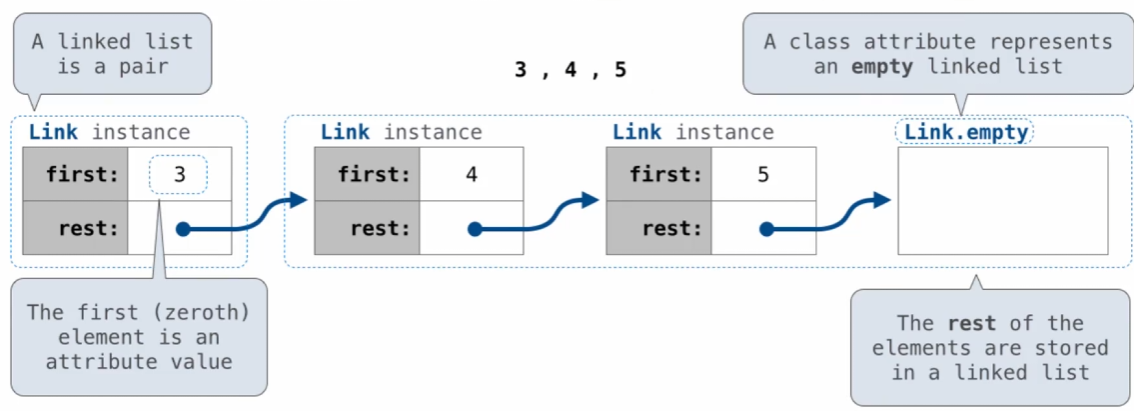

In [1]:
class Link:
    empty = ()
    
    def __init__(self, first, rest = empty): #不需要自己写empty，default就是empty
        assert rest is Link.empty or isinstance(rest, Link)
        self.first = first
        self.rest = rest
s = Link(3, Link(4, Link(5)))

In [4]:
s.first

3

In [5]:
s.rest.first

4

In [7]:
def range_link(start, end):
    return Link(start, range_link(start + 1, end)) if start < end else Link.empty

In [10]:
def map_link(f, s):
    return s if s is Link.empty else Link(f(s.first), map_link(f,s.rest))

In [12]:
def filter_link(f, s):
    if s is Link.empty:
        return s
    fil_rest = filter_link(f, s.rest)
    if f(s.first):
        return Link(s.first, fil_rest)
    else:
        return fil_rest

In [20]:
s1 = map_link(lambda x: x * x, range_link(1, 5))
s2 = filter_link(lambda x: x % 2 == 0, range_link(1, 5))

In [18]:
s1.first

1

In [21]:
s1.rest.first

4

In [22]:
s2.first

2

In [23]:
s2.rest.first

4

# 链表实例

In [24]:
s = Link(1, Link(2, Link(3)))

In [27]:
t = s.rest
t.rest = s

In [53]:
def print_linkx(Link, maxiter = 20):
    if maxiter == 0 or Link is Link.empty:
        return 
    else:
        maxiter -= 1
        print(Link.first)
        print(print_linkx(Link.rest, maxiter - 1))

In [ ]:
print_linkx(s)

t是s的rest，同时s是t的rest（有趣的循环结构！）

# 练习：在有序列表中加入元素

In [57]:
def add(s, v):
    """s是严格递增链表"""
    assert s is not Link.empty
    if s.first > v:
        s.first, s.rest = v, Link(s.first, s.rest)
    elif s.first < v and empty(s.rest):
        s.rest = Link(v)
    elif s.first < v:
        add(s.rest, v)
    return s

In [60]:
add(s, 4).rest.rest.rest.first

4

# 树类

复习：<br>
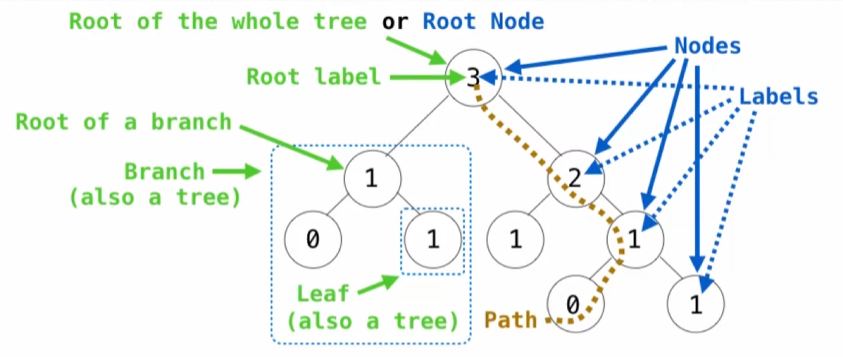<br>
有两种方式来表示一个树：
1. 递归方式：一个树从根节点向叶子节点生长，除了叶子节点，每个节点都有分支（分支也是树）
2. 相关方式：树中的每个位置叫做节点（Node），描述与别的节点的相对位置，谁是谁的子节点（或父节点）。其中每个节点中有一个值（label）

In [12]:
class Tree:
    def __init__(self, label, branches=[]):
        self.label = label
        for branch in branches:
            assert isinstance(branch, Tree)
        self.branches = list(branches)
        
    def __repr__(self):
        if self.branches:
            branch_str = ', ' + repr(self.branches)
        else:
            branch_str = ''
        return f'Tree({repr(self.label)}{branch_str})'
        
    def __str__(self):
        return '\n'.join(self.indented())

    def indented(self):
        '''生成标签的缩进表示'''
        '''
        >>> t = Tree('a', [Tree('b'), Tree('c', [Tree('d')])])
        >>> indented(t)
        ['a', '  b', '  c', '    d']
        '''
        lines = []
        for b in self.branches: #遍历所有分支
            for line in b.indented(): 
                lines.append('  ' + line)
        return [str(self.label)] + lines
    
    def is_leaf(self):
        return not self.branches

In [13]:
def fib_tree(n):
    if n == 0 or n == 1:
        return Tree(n)
    else:
        left = fib_tree(n-2)
        right = fib_tree(n-1)
        fib_n = left.label + right.label
        return Tree(fib_n, [left, right])

In [14]:
print(fib_tree(4))

3
  1
    0
    1
  2
    1
    1
      0
      1


In [15]:
fib_tree(4)

Tree(3, [Tree(1, [Tree(0), Tree(1)]), Tree(2, [Tree(1), Tree(1, [Tree(0), Tree(1)])])])

In [16]:
def leaves(t):
    if t.is_leaf():
        return [t.label]
    else:
        all_leaves = []
        for b in t.branches:
            all_leaves.extend(leaves(b))
        return all_leaves

In [18]:
def height(t):
    if t.is_leaf():
        return 0
    else:
        return 1 + max([height(b) for b in t.branches])

In [19]:
height(fib_tree(6))

5

# 树的可变操作

In [20]:
def prune(t, n):
    '''删除所有标签为n的子树'''
    t.branches = [b for b in t.branches if b.label != n]
    for b in t.branches:
        prune(b, n)

# 一道hw6的好题

**Q5: Two List**
Implement a function two_list that takes in two lists and returns a linked list. The first list contains the values that we want to put in the linked list, and the second list contains the number of each corresponding value. Assume both lists are the same size and have a length of 1 or greater. Assume all elements in the second list are greater than 0.

In [1]:
class Link:
    empty = ()

    def __init__(self, first, rest=empty):
        assert rest is Link.empty or isinstance(rest, Link)
        self.first = first
        self.rest = rest

    def __repr__(self):
        if self.rest is not Link.empty:
            rest_repr = ', ' + repr(self.rest)
        else:
            rest_repr = ''
        return 'Link(' + repr(self.first) + rest_repr + ')'

    def __str__(self):
        string = '<'
        while self.rest is not Link.empty:
            string += str(self.first) + ' '
            self = self.rest
        return string + str(self.first) + '>'

In [ ]:
def two_list(vals, counts):
    """
    >>> a = [1, 3, 2]
    >>> b = [2, 2, 1]
    >>> c = two_list(a, b)
    >>> c
    Link(1, Link(1, Link(3, Link(3, Link(2)))))
    """
    r = Link(0) #里面的数是多少无所谓
    s = r
    for i in range(len(vals)):
        for _ in range(counts[i]):
            s.rest = Link(vals[i])
            s = s.rest
    return r.rest

这段代码不仅可以加深你对链表的理解，更加深你对Python面向对象编程的理解，让我们开始！<br>
大概很多人在学链表的时候会渐渐忘掉Link实际上是一个类，说明CS61A的数据抽象做得很好，但是我们从OOP的角度看，理解会清晰很多，尤其是一二两行<br>

先看看这段代码，你觉得和上述代码一样吗？
```py
r = 2
s = r
s = 3
```

首先，Link(0)返回一个对象，被r接受，接着再把r传给s。如此，r和s都**指向一个对象**——`Link(0)`<br>
接着，for循环不难理解，但是其内的语句是重中之重：<br>
首先`s.rest = Link(...)`操作s绑定的对象，让他后面加了一个单元链表（*想想r现在长什么样？*）。<br>
再看看下面一句，`s = s.rest`这里s指向的对象变了——是`Link(0)`后的链表了。<br>
总结一下这两句，s后面增一段，s指向的位置移动一位。这时你会发现，r一直没动，但是r指向的对象在不断变长